# Progress Report 1 — Week 1-2
## Transformers in Financial Derivative Pricing: Solving the Black-Scholes Equation using PINNsFormer
**Ceyhan Doğan — CMP712 — Hacettepe University**

---

### Contents
1. Problem Definition & Motivation
2. Literature Review Summary
3. Domain Transfer: Physical → Financial
4. Synthetic Dataset Generation (Call & Put)
5. Baseline: Standard PINN vs Analytical Solution
6. Summary & Next Steps

---
## 1. Problem Definition & Motivation

The **Black-Scholes PDE** governs European option pricing:

$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0$$

where $V$ is the option value, $S$ the underlying asset price, $t$ the time, $r$ the risk-free rate, and $\sigma$ the volatility.

**Why PINNs?** Traditional solvers (finite element, finite difference) are expensive when rerunning across parameter sweeps. PINNs embed the PDE into the loss function and solve without labeled data.

**Why PINNsFormer?** Vanilla PINNs use *pointwise* training — each collocation point is treated independently. This fails to capture continuous temporal evolution and causes spectral bias in high-frequency regions. PINNsFormer replaces pointwise training with a *sequential* loss via a Transformer encoder-decoder, which explicitly models temporal dependencies.

---
## 2. Literature Review Summary

| Reference | Contribution | Limitation |
|-----------|-------------|------------|
| Raissi et al. (2019) | Foundational PINN framework — PDE in loss | Pointwise; spectral bias |
| Dhiman & Hu (2023) | PINN for BS call/put; ~30% gain over analytic benchmarks on market data | Convergence issues near boundaries |
| Nuugulu et al. (2025) | PINN vs pure data-driven on BS & Heston; PINN superior in stability | Both still pointwise |
| **Zhao et al. (2024)** | **PINNsFormer**: Transformer + Wavelet activation + sequential loss → fixes spectral bias | Not applied to finance yet |

**This project** bridges the gap: adapts PINNsFormer to the Black-Scholes domain.

---
## 3. Domain Transfer: Physical → Financial

PINNsFormer was designed for physics PDEs with inputs $(x, t)$. We map:

| PINNsFormer | Black-Scholes | Notes |
|-------------|--------------|-------|
| $x$ (space) | $S$ (asset price) | |
| $t$ (time)  | $\tau = T - t$ (time-to-maturity) | Reversed so $\tau=0$ is the terminal condition |
| $u(x,t)$    | $V(S,\tau)$ (option price) | |

Working with $\tau$ instead of $t$ converts the terminal condition ($V(S,T)=$ payoff) into an **initial condition** ($V(S,0)=$ payoff), which is the natural form for PINNs.

The PDE in $(S, \tau)$ notation becomes:
$$\frac{\partial V}{\partial \tau} - \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - rS\frac{\partial V}{\partial S} + rV = 0$$

**Boundary & terminal conditions (European call):**
- Terminal: $V(S, 0) = \max(S - K, 0)$
- Left BC: $V(S_{\min}, \tau) \approx 0$ (deep OTM)
- Right BC: $V(S_{\max}, \tau) \approx S_{\max} - K e^{-r\tau}$ (deep ITM)

---
## 4. Synthetic Dataset Generation

In [1]:
import sys, os
sys.path.insert(0, os.path.join('bs_pinn'))
sys.path.insert(0, os.path.join('pinnsformer'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from black_scholes_data import (
    generate_dataset, bs_call, bs_put,
    sample_residual_points, sample_terminal_points, sample_boundary_points
)

# ── Parameters ────────────────────────────────────────────────────────────────
K     = 100.0   # strike price
r     = 0.05    # risk-free rate
sigma = 0.20    # volatility
S_MIN, S_MAX = 20.0, 200.0
TAU_MIN, TAU_MAX = 0.0, 1.0   # tau in years

# ── Generate call and put datasets ───────────────────────────────────────────
ds_call = generate_dataset(S_min=S_MIN, S_max=S_MAX, tau_min=TAU_MIN, tau_max=TAU_MAX,
                            K=K, r=r, sigma=sigma, n_S=100, n_tau=100, option_type='call')
ds_put  = generate_dataset(S_min=S_MIN, S_max=S_MAX, tau_min=TAU_MIN, tau_max=TAU_MAX,
                            K=K, r=r, sigma=sigma, n_S=100, n_tau=100, option_type='put')

print(f'Call price grid shape : {ds_call["V_mesh"].shape}')
print(f'Put  price grid shape : {ds_put["V_mesh"].shape}')
print(f'\nSample call price at S=100, tau=0.5 : {bs_call(100, K, r, sigma, 0.5):.4f}')
print(f'Sample put  price at S=100, tau=0.5 : {bs_put(100, K, r, sigma, 0.5):.4f}')

Call price grid shape : (100, 100)
Put  price grid shape : (100, 100)

Sample call price at S=100, tau=0.5 : 6.8887
Sample put  price at S=100, tau=0.5 : 4.4197


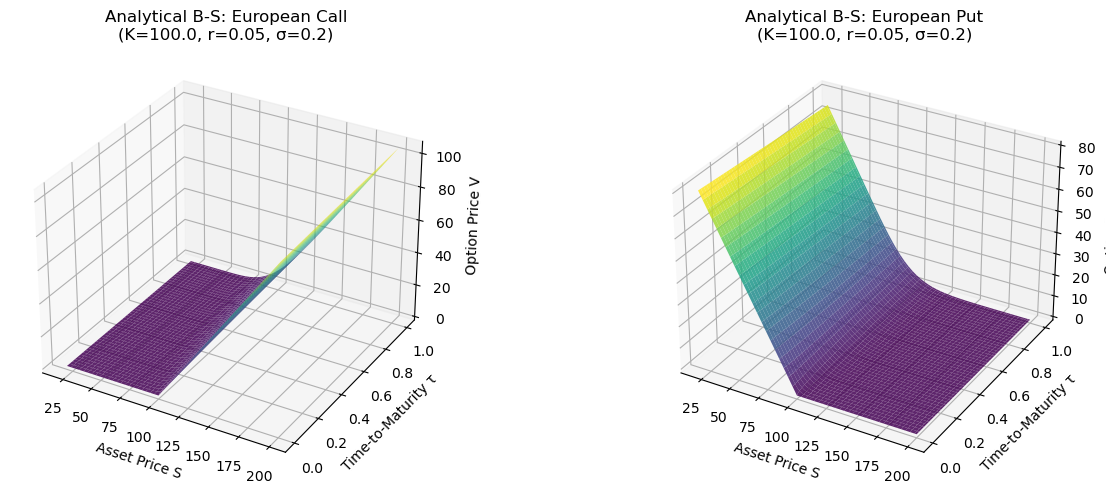

In [2]:
# ── Visualise the price surfaces ──────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))

for idx, (ds, title) in enumerate([(ds_call, 'European Call'), (ds_put, 'European Put')]):
    ax = fig.add_subplot(1, 2, idx+1, projection='3d')
    ax.plot_surface(ds['S_mesh'], ds['tau_mesh'], ds['V_mesh'],
                    cmap='viridis', alpha=0.85)
    ax.set_xlabel('Asset Price S')
    ax.set_ylabel('Time-to-Maturity τ')
    ax.set_zlabel('Option Price V')
    ax.set_title(f'Analytical B-S: {title}\n(K={K}, r={r}, σ={sigma})')

plt.tight_layout()
plt.savefig('bs_pinn/fig_price_surfaces.png', dpi=120)
plt.show()

In [3]:
# ── Verify put-call parity: C - P = S - K*exp(-r*tau) ────────────────────────
parity_lhs = ds_call['V_mesh'] - ds_put['V_mesh']
parity_rhs = ds_call['S_mesh'] - K * np.exp(-r * ds_call['tau_mesh'])

# at tau=0 the rhs can differ (exp(-r*0)=1), use tau>0 rows
mask = ds_call['tau_mesh'] > 0
max_err = np.max(np.abs(parity_lhs[mask] - parity_rhs[mask]))
print(f'Put-call parity max error: {max_err:.2e}  (should be ~0)')

Put-call parity max error: 1.42e-14  (should be ~0)


---
## 5. Baseline: Standard PINN vs Analytical Solution

We train a vanilla 6-layer tanh PINN on the Black-Scholes problem and compare its predictions with the closed-form Black-Scholes prices.

In [4]:
import torch
from bs_pinn_model import BS_PINN, rMAE, rRMSE

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

# ── Collocation points ────────────────────────────────────────────────────────
N_RES = 2000   # interior residual points
N_TC  = 500    # terminal condition points
N_BC  = 500    # boundary points per side

S_res, tau_res = sample_residual_points(N_RES, S_MIN, S_MAX, 1e-3, TAU_MAX)
S_tc, tau_tc, V_tc = sample_terminal_points(N_TC, S_MIN, S_MAX, K, r, sigma)
(S_bcl, tau_bcl, V_bcl), (S_bcr, tau_bcr, V_bcr) = sample_boundary_points(
    N_BC, 1e-3, TAU_MAX, S_MIN, S_MAX, K, r, sigma
)

# ── Training ──────────────────────────────────────────────────────────────────
pinn = BS_PINN(hidden_dim=64, num_layer=6, sigma=sigma, r=r,
               lam1=1.0, lam2=10.0, lam3=10.0, lr=1e-3, device=DEVICE)

N_EPOCHS = 10000
log_every = 1000
history = []

train_args = (S_res, tau_res, S_tc, tau_tc, V_tc,
              S_bcl, tau_bcl, V_bcl, S_bcr, tau_bcr, V_bcr)

for epoch in range(1, N_EPOCHS + 1):
    losses = pinn.train_step(*train_args)
    history.append(losses)
    if epoch % log_every == 0:
        print(f'Epoch {epoch:5d} | total={losses[0]:.4e} | '
              f'L_pde={losses[1]:.4e} | L_tc={losses[2]:.4e} | L_bc={losses[3]:.4e}')

print('Training complete.')

Using device: cpu


Epoch  1000 | total=2.4282e+04 | L_pde=5.1073e+01 | L_tc=1.6438e+02 | L_bc=2.2587e+03


Epoch  2000 | total=1.4477e+03 | L_pde=1.0171e+02 | L_tc=3.4169e+00 | L_bc=1.3118e+02


Epoch  3000 | total=1.4150e+02 | L_pde=3.2339e+01 | L_tc=7.1603e-01 | L_bc=1.0200e+01


Epoch  4000 | total=3.1434e+01 | L_pde=9.1431e+00 | L_tc=4.2154e-01 | L_bc=1.8075e+00


...

Epoch  6000 | total=2.6299e+01 | L_pde=1.8282e+00 | L_tc=7.0746e-01 | L_bc=1.7396e+00


Epoch  7000 | total=2.8443e+00 | L_pde=1.4846e+00 | L_tc=6.1915e-02 | L_bc=7.4049e-02


Epoch  8000 | total=4.0890e+00 | L_pde=1.3199e+00 | L_tc=9.8804e-02 | L_bc=1.7811e-01


Epoch  9000 | total=1.9209e+01 | L_pde=5.2348e-01 | L_tc=4.8660e-01 | L_bc=1.3820e+00


Epoch 10000 | total=1.7563e+00 | L_pde=3.6904e-01 | L_tc=3.7547e-02 | L_bc=1.0118e-01
Training complete.


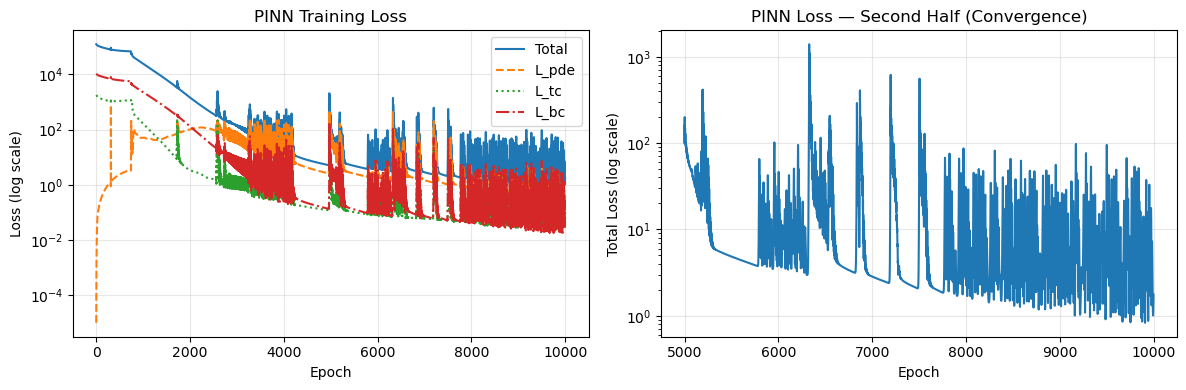

In [5]:
# ── Loss curves ───────────────────────────────────────────────────────────────
history = np.array(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history[:, 0], label='Total')
axes[0].semilogy(history[:, 1], label='L_pde', linestyle='--')
axes[0].semilogy(history[:, 2], label='L_tc',  linestyle=':')
axes[0].semilogy(history[:, 3], label='L_bc',  linestyle='-.')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('PINN Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom last 50%
half = len(history) // 2
axes[1].semilogy(range(half, len(history)), history[half:, 0])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Total Loss (log scale)')
axes[1].set_title('PINN Loss — Second Half (Convergence)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bs_pinn/fig_pinn_loss.png', dpi=120)
plt.show()

In [6]:
# ── Evaluate on the full grid ─────────────────────────────────────────────────
S_flat  = ds_call['flat']['S']
tau_flat = ds_call['flat']['tau']
V_true   = ds_call['flat']['V']

V_pred = pinn.predict(S_flat, tau_flat)

# Only evaluate at tau > 0 (exclude terminal boundary which is exact by construction)
mask_eval = tau_flat > 1e-4
rmae  = rMAE(V_pred[mask_eval], V_true[mask_eval])
rrmse = rRMSE(V_pred[mask_eval], V_true[mask_eval])

print(f'Baseline PINN (European Call)')
print(f'  rMAE  = {rmae:.4f}  ({rmae*100:.2f}%)')
print(f'  rRMSE = {rrmse:.4f}  ({rrmse*100:.2f}%)')

Baseline PINN (European Call)
  rMAE  = 0.0043  (0.43%)
  rRMSE = 0.0036  (0.36%)


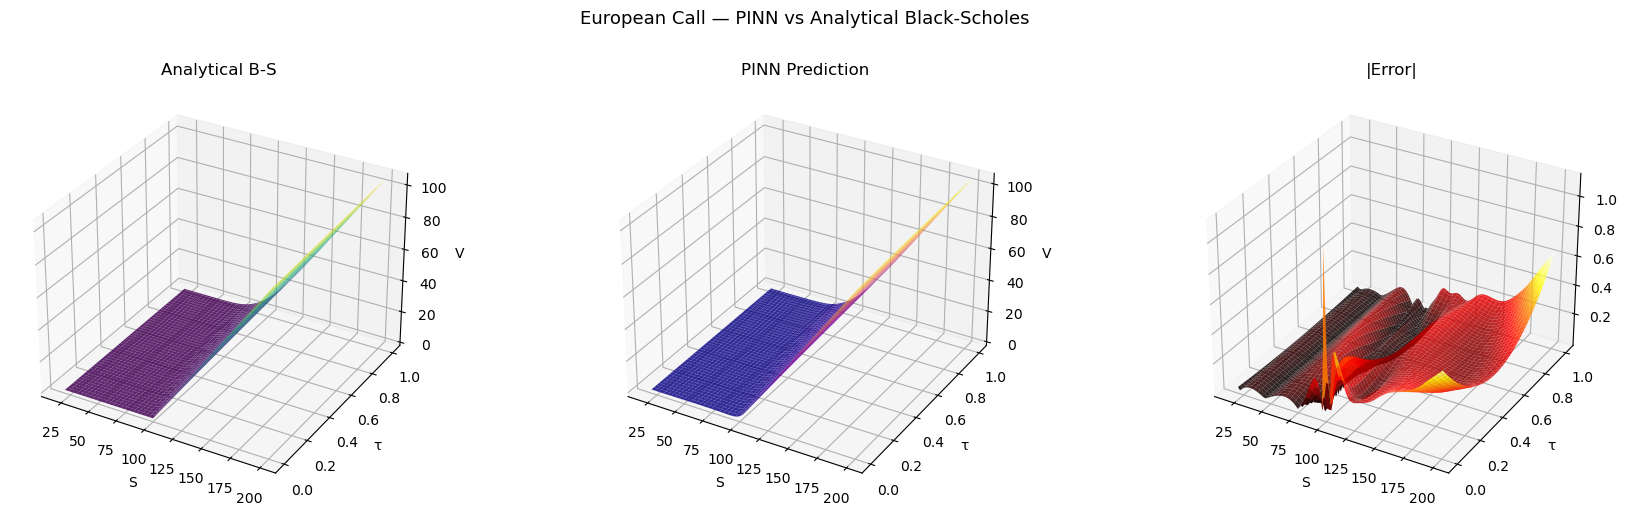

In [7]:
# ── Price surface comparison ───────────────────────────────────────────────────
V_pred_grid = V_pred.reshape(ds_call['V_mesh'].shape)
abs_err_grid = np.abs(V_pred_grid - ds_call['V_mesh'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': '3d'})

for ax, Z, title, cmap in zip(
    axes,
    [ds_call['V_mesh'], V_pred_grid, abs_err_grid],
    ['Analytical B-S', 'PINN Prediction', '|Error|'],
    ['viridis', 'plasma', 'hot']
):
    ax.plot_surface(ds_call['S_mesh'], ds_call['tau_mesh'], Z, cmap=cmap, alpha=0.85)
    ax.set_xlabel('S')
    ax.set_ylabel('τ')
    ax.set_zlabel('V')
    ax.set_title(title)

plt.suptitle('European Call — PINN vs Analytical Black-Scholes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('bs_pinn/fig_pinn_vs_analytical.png', dpi=120)
plt.show()

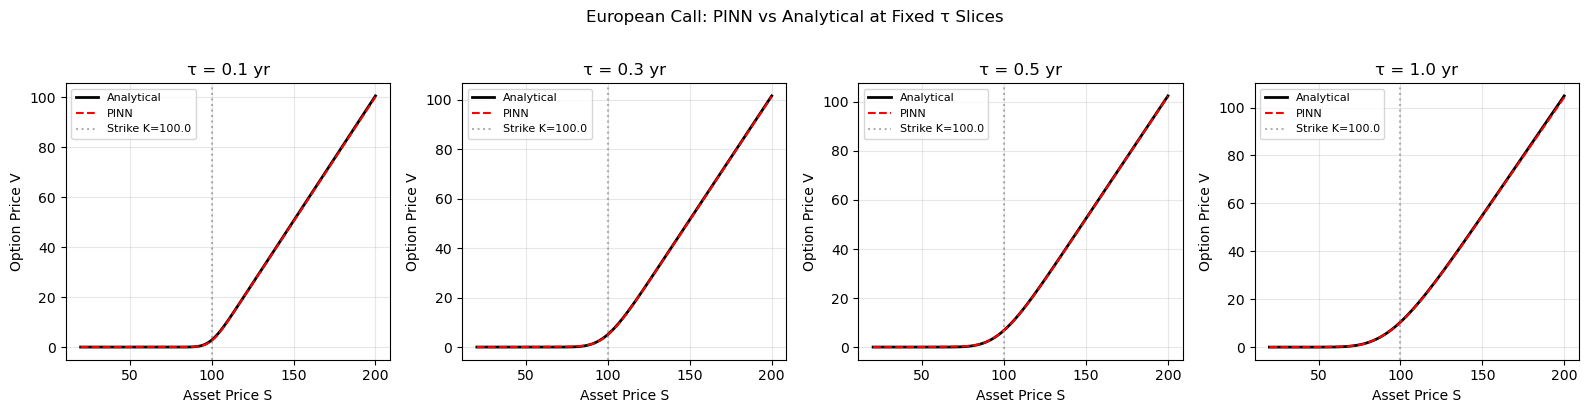

In [8]:
# ── Slice comparison at specific tau values ───────────────────────────────────
S_grid   = ds_call['S_grid']
tau_vals = [0.1, 0.3, 0.5, 1.0]

fig, axes = plt.subplots(1, len(tau_vals), figsize=(16, 4), sharey=False)

for ax, tau_val in zip(axes, tau_vals):
    # analytical
    V_ana = bs_call(S_grid, K, r, sigma, tau_val)
    # PINN prediction
    tau_arr = np.full_like(S_grid, tau_val)
    V_nn  = pinn.predict(S_grid, tau_arr)

    ax.plot(S_grid, V_ana, 'k-',  label='Analytical', linewidth=2)
    ax.plot(S_grid, V_nn,  'r--', label='PINN',       linewidth=1.5)
    ax.axvline(K, color='gray', linestyle=':', alpha=0.6, label=f'Strike K={K}')
    ax.set_xlabel('Asset Price S')
    ax.set_ylabel('Option Price V')
    ax.set_title(f'τ = {tau_val} yr')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('European Call: PINN vs Analytical at Fixed τ Slices', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('bs_pinn/fig_pinn_slices.png', dpi=120)
plt.show()

---
## 6. Summary & Next Steps

### What was accomplished (Week 1–2)

| Task | Status |
|------|--------|
| Cloned PINNsFormer repo, verified models run | ✅ |
| Domain transfer $(x,t) \to (S,\tau)$ implemented | ✅ |
| Synthetic call & put datasets generated via analytical B-S | ✅ |
| Baseline PINN trained & evaluated (rMAE, rRMSE) | ✅ |
| Price surface & slice comparisons plotted | ✅ |

### Key Baseline Observations
- The standard PINN approximates the general shape of the call price surface.
- Largest errors appear **near the strike price** ($S \approx K$) and at **short maturities** — exactly the high-frequency region where the payoff has a kink.
- This confirms the spectral bias issue described in the literature and motivates the Wavelet activation + sequential loss of PINNsFormer.

### Week 3–4 Plan
1. Train the full **BS_PINNsFormer** model and compare to the PINN baseline.
2. Hyperparameter sweep: $\lambda_1, \lambda_2, \lambda_3$; $d_{\text{model}}$; number of Transformer layers.
3. Evaluate on put options and out-of-sample parameter combinations $(K, \sigma)$.
4. Benchmark wall-clock training time PINN vs PINNsFormer.